In [13]:
import os
os.listdir()


[' Array adt assignment(CB.PS.I5DAS22115).ipynb',
 ' case 4 compare sample using z test(hypothesis testing).ipynb',
 ' PLOTING GRAPHS.ipynb',
 ' randomness exam.ipynb',
 ' unit 2 and three.ipynb',
 '.bash_history',
 '.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.js',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.npmrc',
 '.packettracer',
 '.ssh',
 '.vscode',
 '2 and 3(ml).ipynb',
 '2021-2024_F1_Race_Results.xlsx',
 '345.ipynb',
 'AirQuality.csv',
 'amc-backend',
 'anaconda3',
 'AppData',
 'Application Data',
 'archive (7).zip',
 'archive.zip',
 'arduinorealworld.csv',
 'arduinorealworld.ipynb',
 'ASNM-CDX-2009.csv',
 'ASNM-NBPOv2.csv',
 'ASNM-TUN.csv',
 'Asset-Management-System',
 'basics of python .ipynb',
 'bfs.ipynb',
 'brain_tumor_images.gif',
 'BreastW.ipynb',
 'CB.PS.I5DAS22115(10_04_24).ipynb',
 'CB.PS.I5DAS22115(DAA LAB 27).ipynb',
 'CB.PS.I5DAS22115(GRAPH_ANALYTICS).ipynb',
 'CB.PS.I5DAS22115(HUFFMAN-CODING).ipynb',
 'CB.PS.I5D

In [14]:
import zipfile

zip_path = "archive (7).zip"  # Replace with your actual ZIP file name
extract_path = "dataset/Testing/glioma"  # Folder where images will be extracted

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete! Files are in:", extract_path)


Extraction complete! Files are in: dataset/Testing/glioma


In [15]:
import glob



image_files = glob.glob(os.path.join(extract_path, "*.jpg"))  # Change extension if needed
print(f"Found {len(image_files)} images.")


Found 300 images.


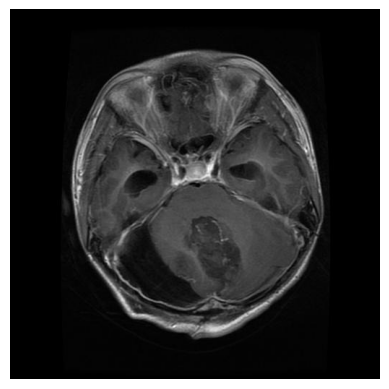

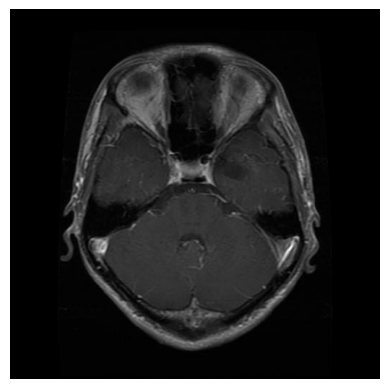

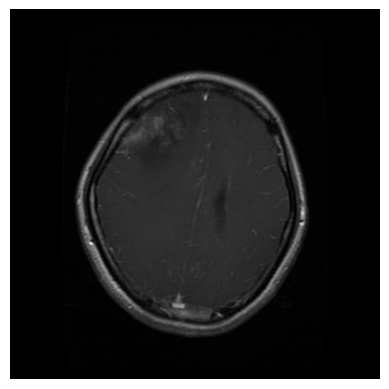

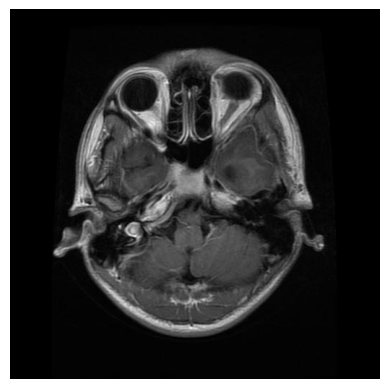

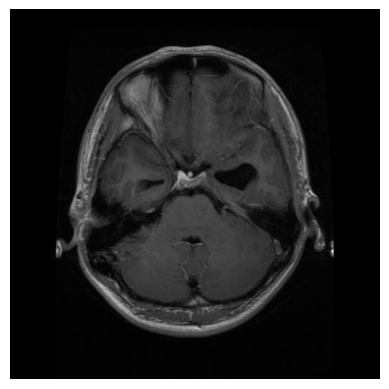

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

# Load and display images
image_files = glob.glob(os.path.join(extract_path, "*.jpg"))  # Adjust extension if needed

for img_path in image_files[:5]:  # Display first 5 images
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeUniform, GlorotUniform
from sklearn.preprocessing import StandardScaler
import numpy as npa
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import losses
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

C:\Users\leksh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [6]:
import pathlib

# Define the base dataset directory
data_dir = pathlib.Path("dataset/Testing/glioma")  # Update with your correct base path

# Define Training and Testing directories
train_dir = data_dir / "Training"
test_dir = data_dir / "Testing"

print("Training Directory:", train_dir)
print("Testing Directory:", test_dir)


Training Directory: dataset\Testing\glioma\Training
Testing Directory: dataset\Testing\glioma\Testing


In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_dir = str(data_dir / "Training") 
test_dir = str(data_dir / "Testing")  

In [9]:
# Define image dimensions and batch size
img_height = 224  # Set desired image height
img_width = 224   # Set desired image width
batch_size = 32   # Set batch size

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical"
)

print("Class Labels:", train_generator.class_indices)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Class Labels: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


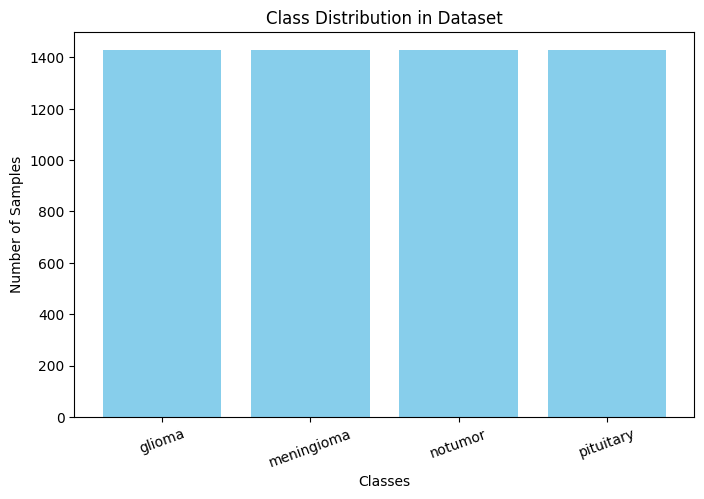

In [10]:
import matplotlib.pyplot as plt

class_labels = list(train_generator.class_indices.keys())
class_counts = [len(train_generator.filepaths) // train_generator.num_classes] * len(class_labels)

plt.figure(figsize=(8, 5))
plt.bar(class_labels, class_counts, color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Class Distribution in Dataset")
plt.xticks(rotation=20)
plt.show()

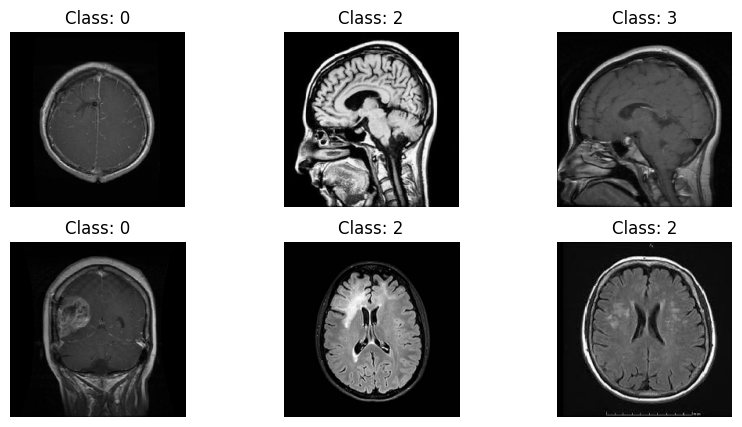

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_generator)  

plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Class: {np.argmax(y_batch[i])}") 
    plt.axis("off")
plt.show()

In [12]:
#Apply Data Augmentation (For Training Set)
train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=20,  # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Horizontal flipping
    fill_mode="nearest",  # Filling strategy for empty pixels
    validation_split=0.2  # Splitting training into train and validation
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Class Labels: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


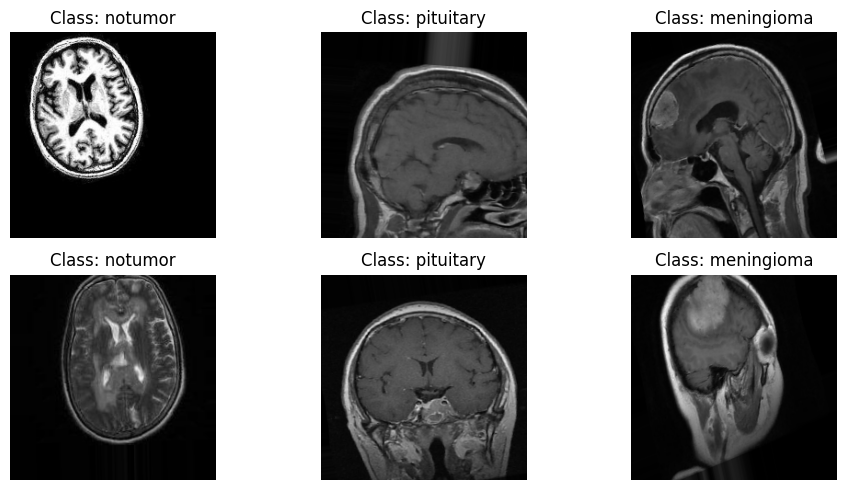

In [13]:
#  Apply Only Rescaling to Test Set (No Augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

#  Load Training and Validation Data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"  # Take 80% of the data as training
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"  # Take 20% of the data as validation
)

#  Load Test Data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False  # Keep order for evaluation
)

#  Print Class Labels
print("Class Labels:", train_generator.class_indices)

#  Visualize Augmented Images
x_batch, y_batch = next(train_generator)  

plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_batch[i])
    
    # Convert one-hot encoded labels to class names
    class_labels = list(train_generator.class_indices.keys())
    class_index = np.argmax(y_batch[i])  
    plt.title(f"Class: {class_labels[class_index]}")
    
    plt.axis("off")

plt.tight_layout()
plt.show()


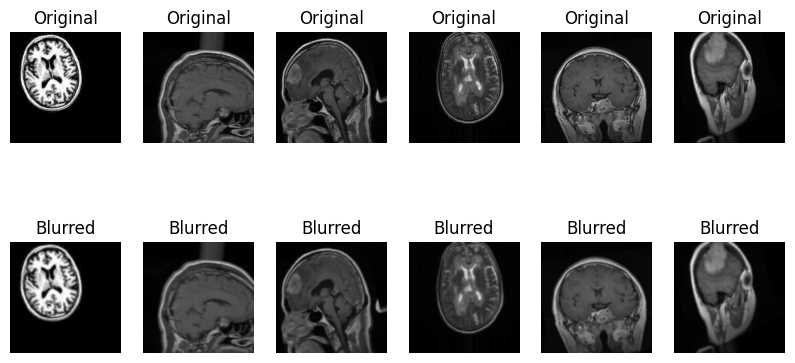

In [15]:
def apply_gaussian_blur(image, kernel_size=(5,5), sigma=0):
    # Ensure image is in uint8 format
    image = (image * 255).astype(np.uint8)
    
    # Apply Gaussian blur
    return cv2.GaussianBlur(image, kernel_size, sigma)

# Apply Gaussian Blur
gaussian_blurred_images = np.array([apply_gaussian_blur(img) for img in x_batch])

# Display Results
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(x_batch[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 6, i+7)
    plt.imshow(gaussian_blurred_images[i])
    plt.title("Blurred")
    plt.axis("off")

plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5584831..2.4613662].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2636646..4.842295].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1574429..5.3523664].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7670335..5.088357].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1701885..4.4562764].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.80094606..4.129992].


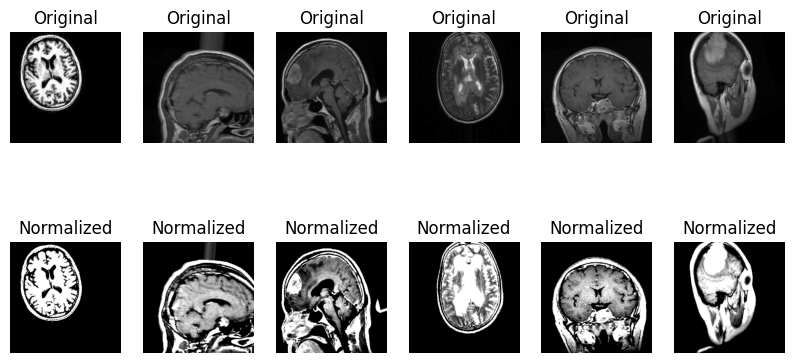

In [16]:
def normalize_image(image):
    # Convert image to float
    image = image.astype(np.float32)
    
    # Zero-center the image
    mean = np.mean(image, axis=(0, 1), keepdims=True)  # Compute mean per channel
    std = np.std(image, axis=(0, 1), keepdims=True) + 1e-7  # Compute std deviation
    
    return (image - mean) / std  # Standardization

# Apply Normalization
normalized_images = np.array([normalize_image(img) for img in x_batch])

# Display Results
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(x_batch[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 6, i+7)
    plt.imshow(normalized_images[i])
    plt.title("Normalized")
    plt.axis("off")

plt.show()


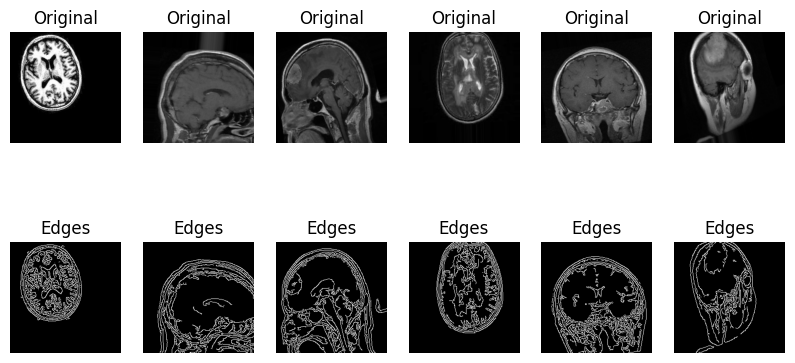

In [17]:
def apply_canny_edges(image):
    # Convert to grayscale
    gray = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    
    # Apply Canny Edge Detection
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    
    return edges

# Apply Canny Edge Detection
edge_detected_images = np.array([apply_canny_edges(img) for img in x_batch])

# Display Results
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(x_batch[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 6, i+7)
    plt.imshow(edge_detected_images[i], cmap="gray")
    plt.title("Edges")
    plt.axis("off")

plt.show()


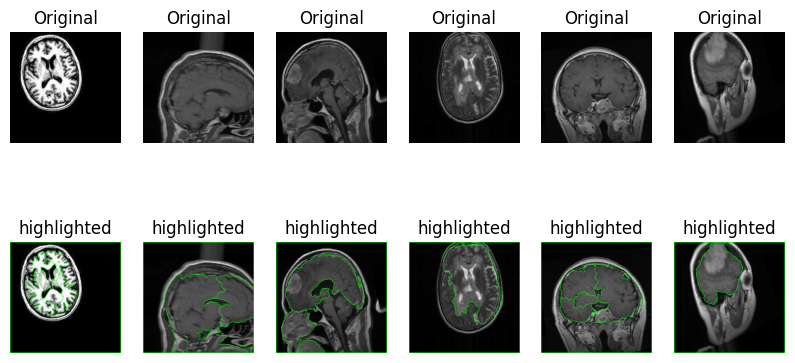

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def watershed_segmentation(image):
    # Convert to grayscale
    gray = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

    # Apply Otsu Thresholding
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Remove noise with Morphological Operations
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Sure background area
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # Finding sure foreground area
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

    # Unknown region
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Marker labeling
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Convert markers to 32-bit int
    markers = np.int32(markers)

    # Convert image to BGR for watershed
    image_bgr = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

    # Apply Watershed Algorithm
    cv2.watershed(image_bgr, markers)

    # Highlight tumor boundaries
    image_bgr[markers == -1] = [0, 255, 0]  # Green boundary

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Apply Watershed Algorithm
watershed_images = np.array([watershed_segmentation(img) for img in x_batch])

# Display Results
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.imshow(x_batch[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 6, i+7)
    plt.imshow(watershed_images[i])
    plt.title("highlighted")
    plt.axis("off")

plt.show()


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define Model
model = Sequential([
    # Convolutional Layers
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(img_height, img_width, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Global Average Pooling
    GlobalAveragePooling2D(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output Layer (Number of Classes)
    Dense(len(train_generator.class_indices), activation='softmax')
])

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Print Model Summary
model.summary()


C:\Users\leksh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,172 (465.52 KB)

 Trainable params: 118,724 (463.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train Model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=[early_stopping, reduce_lr]
)


C:\Users\leksh\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 414s 3s/step - accuracy: 0.5197 - loss: 1.0779 - val_accuracy: 0.2967 - val_loss: 1.6905 - learning_rate: 0.0010
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.6695 - loss: 0.8092 - val_accuracy: 0.3760 - val_loss: 2.2495 - learning_rate: 0.0010
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.7328 - loss: 0.7222 - val_accuracy: 0.3951 - val_loss: 2.7409 - learning_rate: 0.0010
Epoch 4/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.7488 - loss: 0.6624 - val_accuracy: 0.6323 - val_loss: 1.0768 - learning_rate: 0.0010
Epoch 5/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.7649 - loss: 0.6025 - val_accuracy: 0.6644 - val_loss: 0.8499 - learning_rate: 0.0010
Epoch 6/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.7917 - loss: 0.5585 - val_accuracy: 0.5919 - val_loss: 1.1002 - learning_rate: 0.0010
Epoch 7/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.8079 - loss: 0.

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 351ms/step - accuracy: 0.7253 - loss: 0.6406
Test Accuracy: 80.47%
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step
              precision    recall  f1-score   support

      glioma       0.92      0.71      0.80       300
  meningioma       0.63      0.54      0.58       306
     notumor       0.80      0.98      0.88       405
   pituitary       0.87      0.93      0.90       300

    accuracy                           0.80      1311
   macro avg       0.81      0.79      0.79      1311
weighted avg       0.80      0.80      0.80      1311



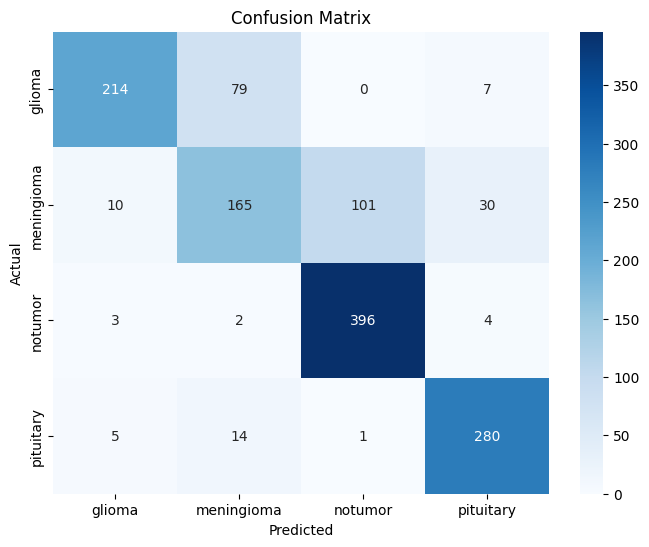

In [21]:
# Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Predict on Test Data
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification Report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred_classes, target_names=list(train_generator.class_indices.keys())))

# Confusion Matrix
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_true, y_pred_classes), annot=True, fmt="d", cmap="Blues", xticklabels=train_generator.class_indices.keys(), yticklabels=train_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 502ms/step


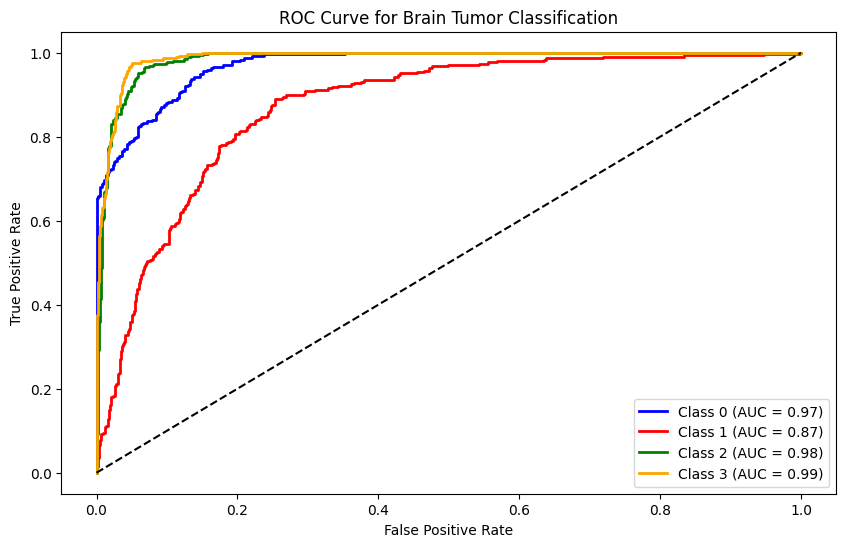

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle

# Get the number of classes
n_classes = len(train_generator.class_indices)

# Get True Labels and Predicted Probabilities
y_true = test_generator.classes  # True labels
y_prob = model.predict(test_generator)  # Predicted probabilities

# One-Hot Encode True Labels for Multi-Class ROC
y_true_one_hot = label_binarize(y_true, classes=list(range(n_classes)))

# Compute ROC Curve & AUC for each class
plt.figure(figsize=(10, 6))
colors = cycle(['blue', 'red', 'green', 'orange'])  # Define colors for each class

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_prob[:, i])  # Compute FPR & TPR
    roc_auc = auc(fpr, tpr)  # Compute AUC
    
    plt.plot(fpr, tpr, color=color, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot the Diagonal Line (Random Guess)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

# Labels and Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Brain Tumor Classification")
plt.legend(loc="lower right")
plt.show()


In [6]:
import os
import glob
import cv2
import numpy as np
from PIL import Image
import imageio

# Load images from dataset
image_files = glob.glob(os.path.join(extract_path, "*.jpg"))  # Adjust path if needed

# Ensure there are images to process
if len(image_files) == 0:
    print("No images found in the directory.")
else:
    images = [Image.open(img_path).resize((256, 256)) for img_path in image_files[:10]]  # First 10 images
    
    # Convert PIL images to OpenCV format
    images_cv = [cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR) for img in images]

    # Function 1: Edge Detection (Canny)
    def edge_detection(image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        return cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    #  Function 2: Skull Stripping (Otsu's Threshold)
    def skull_strip(image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return cv2.bitwise_and(image, image, mask=mask)

    

    # Apply transformations
    transformed_images = []
    for img in images_cv:
        original = img
        edges = edge_detection(img)
        skull_stripped = skull_strip(img)
        
        
        # Stack all transformations for visualization
        combined = np.hstack([original, edges, skull_stripped])
        transformed_images.append(combined)

    # Convert images back to PIL format
    transformed_images_pil = [Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) for img in transformed_images]

    # Save as GIF
    gif_path = "tumor_visualization.gif"
    transformed_images_pil[0].save(
        gif_path,
        save_all=True,
        append_images=transformed_images_pil[1:],
        duration=700,  # Duration per frame (milliseconds)
        loop=0  # Infinite loop
    )

    print(f"GIF saved at: {gif_path}")


GIF saved at: tumor_visualization.gif


Extraction complete! Files are in: dataset/Testing/glioma
Found 300 images.


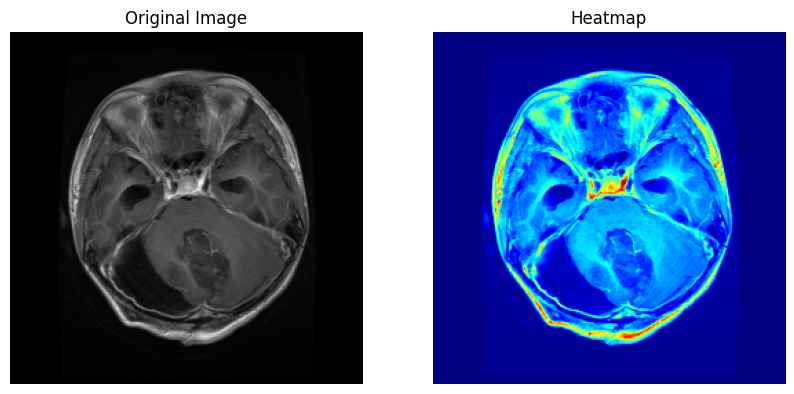

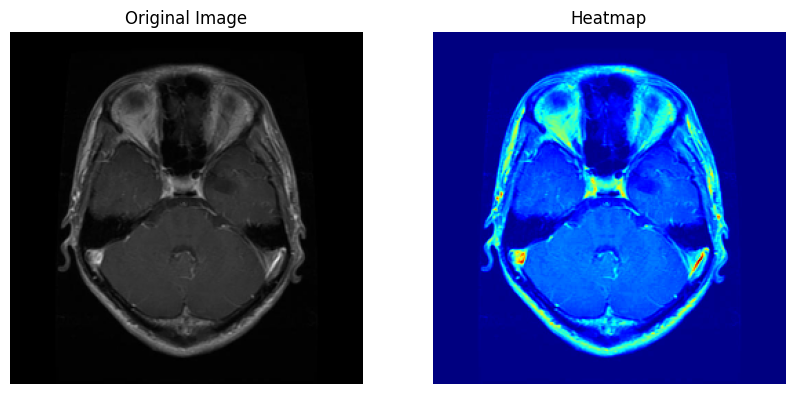

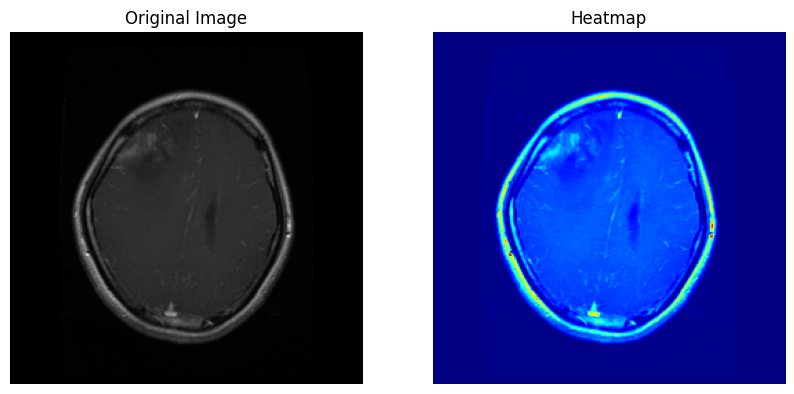

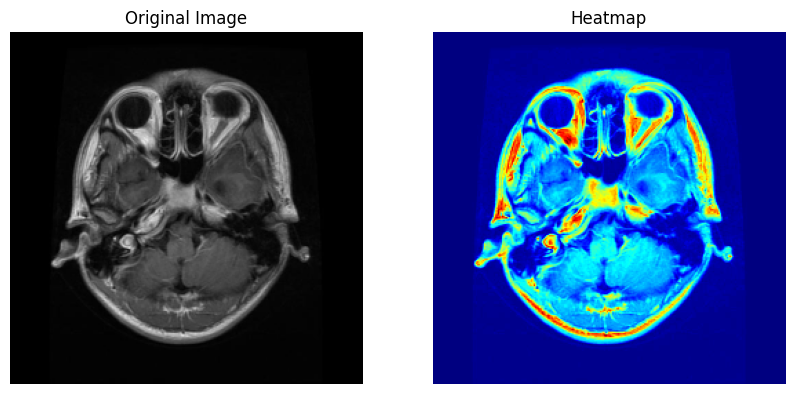

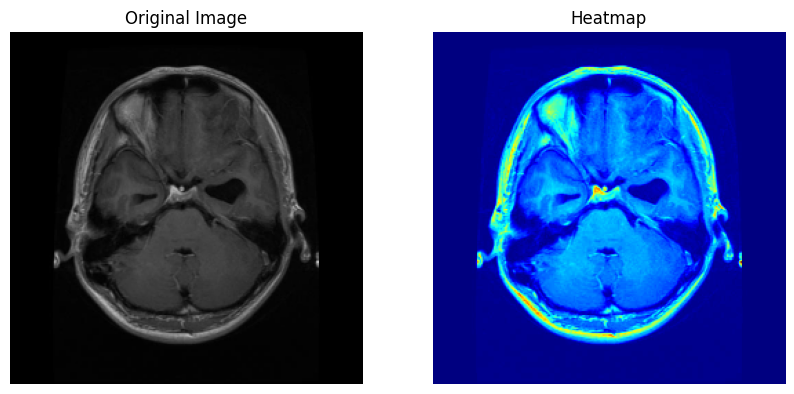

In [12]:
import os
import zipfile
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#  Step 1: Extract the ZIP file
zip_path = "archive (7).zip"  # Replace with your ZIP file name
extract_path = "dataset/Testing/glioma"  # Folder where images will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete! Files are in:", extract_path)

#  Step 2: Load images
image_files = glob.glob(os.path.join(extract_path, "*.jpg"))  # Change extension if needed
print(f"Found {len(image_files)} images.")

#  Step 3: Function to generate heatmaps
def apply_heatmap(image_path):
    image = cv2.imread(image_path)  # Load image in OpenCV format
    image = cv2.resize(image, (256, 256))  # Resize for consistency
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

    # Normalize the grayscale image
    norm_img = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    # Apply heatmap using OpenCV's COLORMAP_JET
    heatmap = cv2.applyColorMap(norm_img, cv2.COLORMAP_JET)
    
    return image, heatmap

#  Step 4: Display the first 5 images with their heatmaps
for img_path in image_files[:5]:  # Display first 5 images
    original, heatmap = apply_heatmap(img_path)

    # Convert OpenCV images to RGB for Matplotlib
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Show original and heatmap side by side
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    ax[0].imshow(original_rgb)
    ax[0].set_title("Original Image")
    ax[0].axis("off")

    ax[1].imshow(heatmap_rgb)
    ax[1].set_title("Heatmap")
    ax[1].axis("off")

    plt.show()


In [ ]:
+